In [2]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [3]:
def make_df(file_path):
    df = pd.DataFrame()

    tritrig_file = uproot.open(file_path)

    # Open ROOT tree
    tree = tritrig_file['preselection']

    # Access branches
    B_vertex = tree['vertex.']
    B_ele = tree['ele.']
    B_pos = tree['pos.']

    # Get arrays of the electron and positron energies as measured with Ecal
    df['ele_E_Ecal'] = np.array(B_ele['ele.energy_'])
    df['pos_E_Ecal'] = np.array(B_pos['pos.energy_'])

    # Get Ecal cluster positions
    df['ele_Ecal_x']= np.array(B_ele['ele.cluster_.x_'])
    df['ele_Ecal_y']= np.array(B_ele['ele.cluster_.y_'])
    df['ele_Ecal_z']= np.array(B_ele['ele.cluster_.z_'])
    df['pos_Ecal_x']= np.array(B_pos['pos.cluster_.x_'])
    df['pos_Ecal_y']= np.array(B_pos['pos.cluster_.y_'])
    df['pos_Ecal_z']= np.array(B_pos['pos.cluster_.z_'])

    # Get Electron and Positron momenta
    arr = B_vertex['vertex.p1_'].array()
    df['ele_Px'] = np.array(arr['fX'])
    df['ele_Py'] = np.array(arr['fY'])
    df['ele_Pz'] = np.array(arr['fZ'])
    arr = B_vertex['vertex.p2_'].array()
    df['pos_Px'] = np.array(arr['fX'])
    df['pos_Py'] = np.array(arr['fY'])
    df['pos_Pz'] = np.array(arr['fZ'])


    return df


In [ ]:
# Create dataframes 
df_tritrig = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/tritrig/tritrig_pulser_smeared_hadd_500files.root')
df_phiKK = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/phiKK/phiKK_2021_v9_pass5.root')
df_wab = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/wab/wab_pulser_smeared_hadd_1000files.root')
df_data = make_df('/Users/mghrear/data/HPS_data/2021_v9_pass5/merged_hps_014272_job64.root')

In [5]:
df_FakeGen_1pt05_kaon = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/FakeGen_1pt05_kaon/FakeGen_1pt05_kaon.root')
df_FakeGen_1pt05_kaon.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_FakeGen_1pt05_kaon_limited.pk')

In [6]:
df_tritrig.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_limited.pk')
df_phiKK.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_limited.pk')
df_wab.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_limited.pk')
df_data.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_data_limited.pk')

# Compare these attributes in data vs. monte carlo 

In [7]:
df_tritrig_study = df_tritrig.copy()
df_phiKK_study = df_phiKK.copy()
df_wab_study = df_wab.copy()
df_data_study = df_data.copy()

In [8]:
df_wab_study

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,ele_Px,ele_Py,ele_Pz,pos_Px,pos_Py,pos_Pz
0,1.207630,1.868672,-158.891953,-55.612038,1449.945435,126.133934,28.137377,1448.840088,0.038164,-0.042302,1.186327,0.052981,0.043023,2.521937
1,1.774696,0.973213,-75.086823,72.854279,1449.397827,239.669815,-45.181431,1449.834595,0.075685,0.088364,1.703275,-0.008497,-0.029491,0.985601
2,0.000000,1.582586,-9999.000000,-9999.000000,-9999.000000,187.930908,47.991165,1449.396118,0.032761,-0.012496,0.624727,0.010489,0.040511,1.360719
3,0.000000,1.163147,-9999.000000,-9999.000000,-9999.000000,265.248413,38.115505,1449.943115,0.060429,-0.039463,2.285753,0.031223,0.026080,1.109284
4,2.122453,1.079019,-74.355423,-65.489746,1449.397827,272.733643,38.664665,1450.051147,0.059183,-0.094509,2.125130,0.025916,0.028927,1.041348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6591,1.692836,1.321587,-110.478333,31.389250,1449.394531,224.996933,-26.316422,1449.614014,0.041700,0.039518,1.689931,0.037056,-0.025001,1.321016
6592,2.166516,1.048201,-49.778351,42.346409,1449.063599,256.979218,-46.383919,1449.943115,0.084548,0.064057,2.398759,0.014838,-0.035850,1.068200
6593,1.915407,1.235070,-95.556969,35.005039,1449.284302,234.040405,-30.695904,1449.614014,0.047402,0.046283,1.806423,0.018189,-0.027685,1.148823
6594,2.117123,0.922872,-55.227386,-44.129669,1449.063599,317.050903,47.138069,1450.371948,0.084314,-0.067019,2.146417,0.019953,0.033433,0.886412


In [ ]:
# Calculate invariant mass and add to dataframe
m_K = 0.493677

def calculate_invariant_mass_Ptot(df):
    # Calculate total electron momentum
    df['e_Ptot'] = np.sqrt(df['ele_Px']**2 + df['ele_Py']**2 + df['ele_Pz']**2)
    # Calculate total positron momentum
    df['p_Ptot'] = np.sqrt(df['pos_Px']**2 + df['pos_Py']**2 + df['pos_Pz']**2)
    df['e_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.e_Ptot**2 / (df.e_Ptot**2  + m_K**2) ) )
    df['p_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.p_Ptot**2 / (df.p_Ptot**2  + m_K**2) ) )
    df['M'] = np.sqrt((df.e_SVT_E_K+df.p_SVT_E_K)**2 - (df.ele_Px+df.pos_Px)**2 - (df.ele_Py+df.pos_Py)**2 - (df.ele_Pz+df.pos_Pz)**2)
    df['Ptot'] = df.e_Ptot + df.p_Ptot

    return df

df_tritrig_study = calculate_invariant_mass_Ptot(df_tritrig_study)
df_phiKK_study = calculate_invariant_mass_Ptot(df_phiKK_study)
df_wab_study = calculate_invariant_mass_Ptot(df_wab_study)
df_data_study = calculate_invariant_mass_Ptot(df_data_study)

df_combined_study = pd.concat([df_tritrig_study[0:27447], df_phiKK_study[0:1], df_wab_study], ignore_index=True, sort=False)  

df_data_study = df_data_study.sample(n=27447+1+len(df_wab_study), random_state=42) 

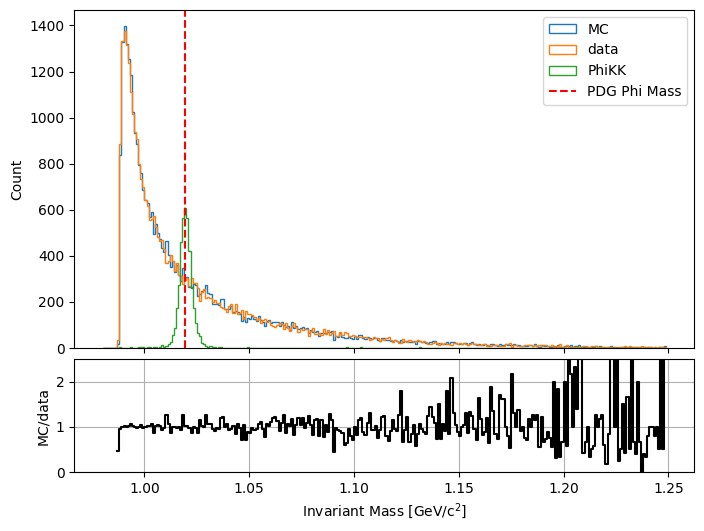

In [60]:
bins = np.arange(0.980, 1.250, 0.001)

mc   = df_combined_study['M'].to_numpy()
data = df_data_study['M'].to_numpy()
phiKK = df_phiKK_study['M'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(mc_counts, data_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(x=1.019461, color='r', linestyle='--', label='PDG Phi Mass')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('MC/data')
ax_bot.set_xlabel('Invariant Mass [GeV/c$^2$]')
ax_bot.set_ylim(0, 2.5)  # adjust as you like
ax_bot.grid(True)

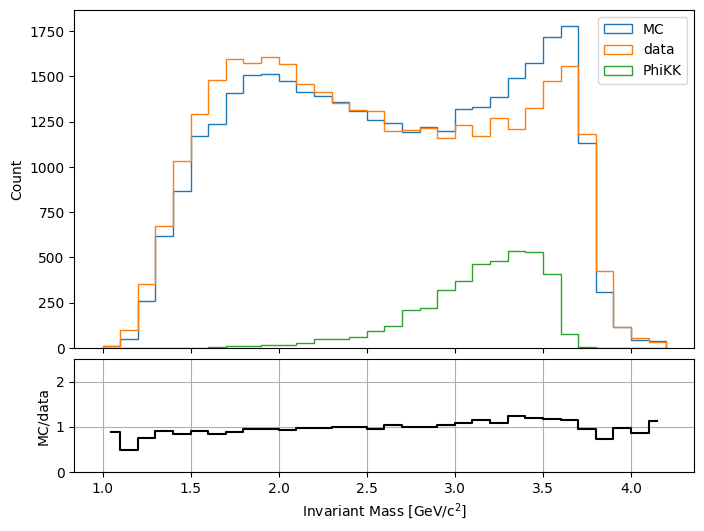

In [59]:
bins = np.arange(1,4.3,0.1)

mc   = df_combined_study['Ptot'].to_numpy()
data = df_data_study['Ptot'].to_numpy()
phiKK = df_phiKK_study['Ptot'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(mc_counts, data_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('MC/data')
ax_bot.set_xlabel('Invariant Mass [GeV/c$^2$]')
ax_bot.set_ylim(0, 2.5)  # adjust as you like
ax_bot.grid(True)

Text(0, 0.5, 'Normalized Entries')

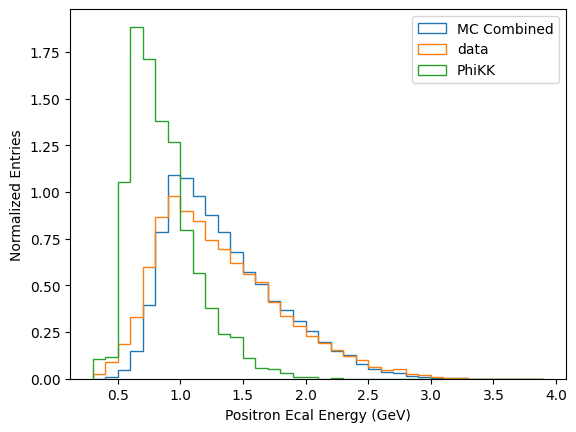

In [38]:
plt.hist(df_combined_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal Energy (GeV)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

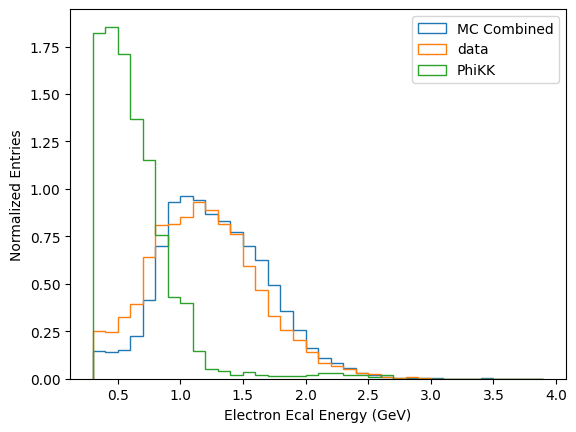

In [39]:
plt.hist(df_combined_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal Energy (GeV)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

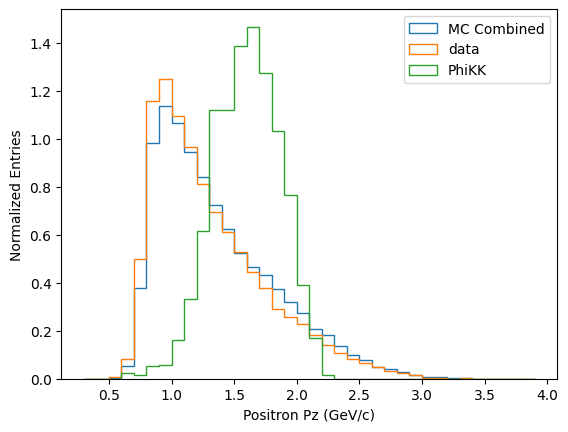

In [40]:
plt.hist(df_combined_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Pz (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

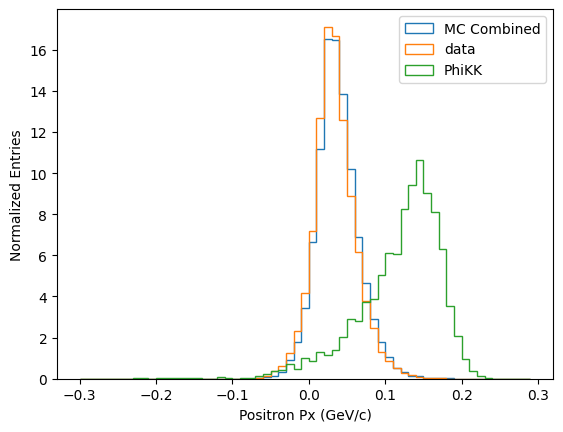

In [41]:
plt.hist(df_combined_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Px (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

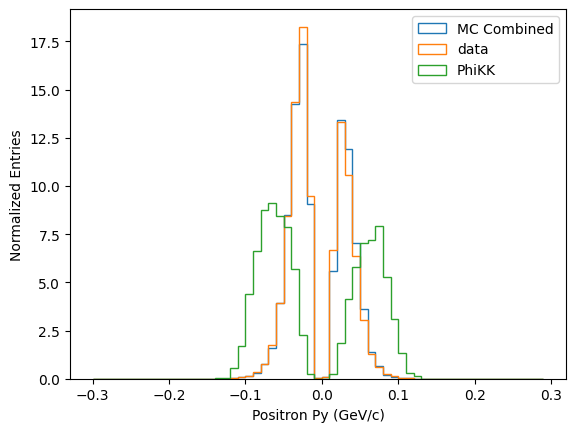

In [42]:
plt.hist(df_combined_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Py (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

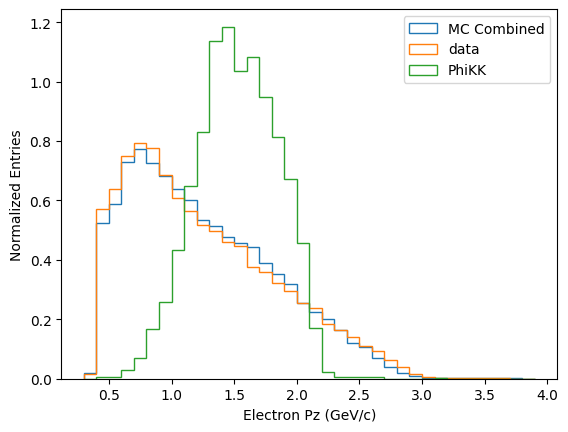

In [43]:
plt.hist(df_combined_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Pz (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

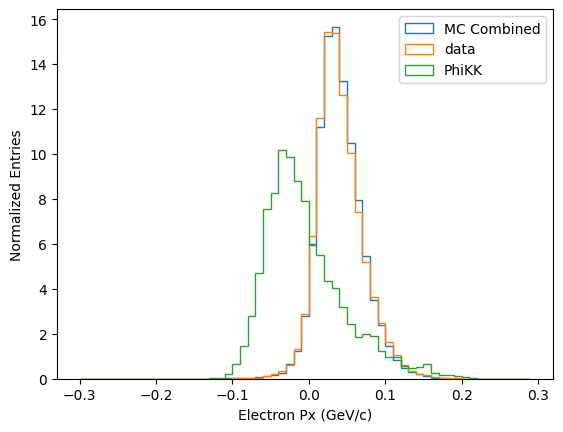

In [44]:
plt.hist(df_combined_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Px (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

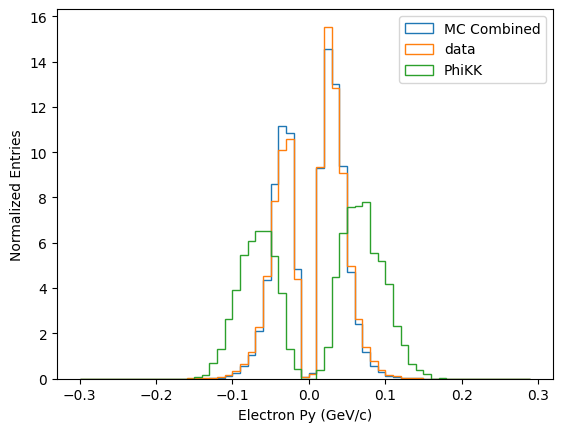

In [45]:
plt.hist(df_combined_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Py (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

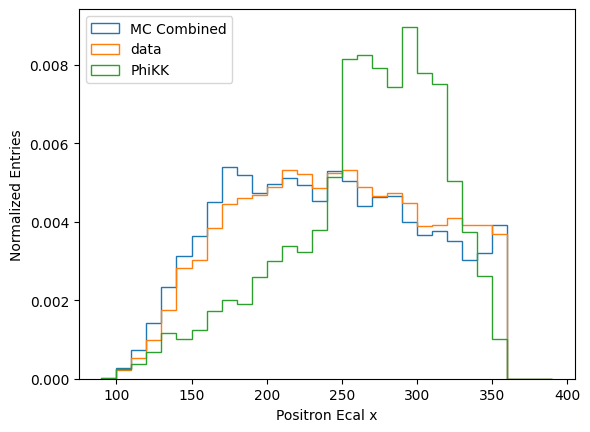

In [46]:
plt.hist(df_combined_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal x')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

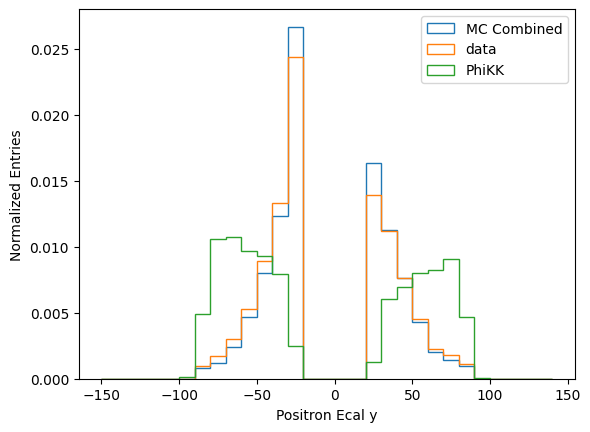

In [47]:
plt.hist(df_combined_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal y')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

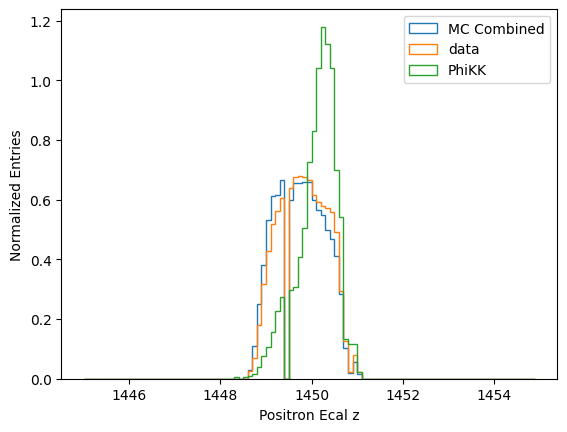

In [48]:
plt.hist(df_combined_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal z')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

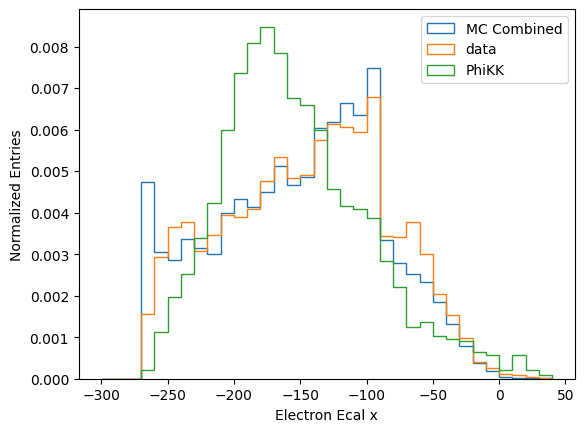

In [49]:
plt.hist(df_combined_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal x')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

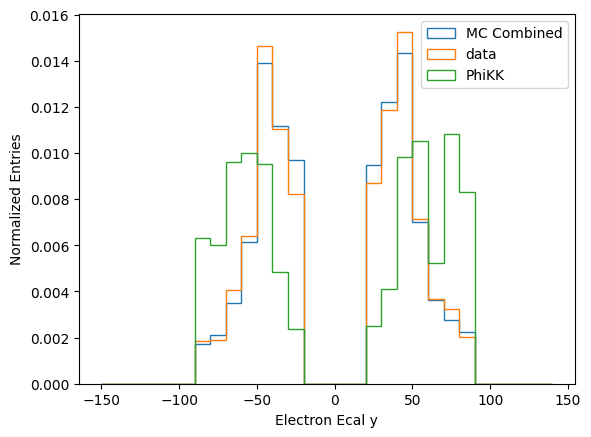

In [50]:
plt.hist(df_combined_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal y')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

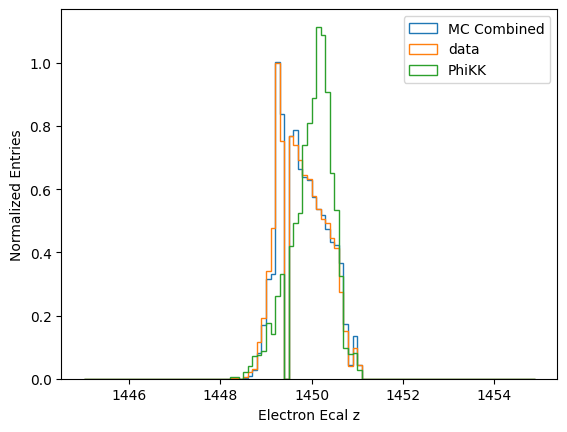

In [51]:
plt.hist(df_combined_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal z')
plt.ylabel('Normalized Entries')
